# Theo Analysis - Round 1

Goal: Develop better theoretical fair values for **ASH_COATED_OSMIUM** and **INTARIAN_PEPPER_ROOT** to support market making.

Current theos:
- ASH: fixed at 10,000
- PEPPER: linear drift `anchor + (t - t0) * 0.001`

## 0. Setup & Data Loading

In [33]:
import os, glob as gl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf

import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({'figure.figsize': (14, 5), 'figure.dpi': 120, 'axes.grid': False, 'grid.alpha': 0.3})

In [2]:
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath(".")), "data")
# Adjust path if running from research/
if not os.path.isdir(DATA_DIR):
    DATA_DIR = os.path.join(os.path.abspath("."), "round-1", "data")
if not os.path.isdir(DATA_DIR):
    DATA_DIR = os.path.join(os.path.abspath(".."), "data")

print(f"Data dir: {DATA_DIR}")

Data dir: C:\Users\minse\OneDrive\Desktop\prosperity\imc-prosperity-4-quantsc\round-1\data


In [3]:
# Load prices
price_files = sorted(gl.glob(os.path.join(DATA_DIR, "prices_round_1_day_*.csv")))
prices = pd.concat([pd.read_csv(f, sep=";") for f in price_files], ignore_index=True)
prices.sort_values(["day", "timestamp"], inplace=True)
prices = prices[prices["mid_price"].notna() & (prices["mid_price"] > 0)].copy()

# Continuous time index
DAY_LEN = 1_000_000
prices["time"] = (prices["day"] - prices["day"].min()) * DAY_LEN + prices["timestamp"]

# Load trades
trade_files = sorted(gl.glob(os.path.join(DATA_DIR, "trades_round_1_day_*.csv")))
trades = pd.concat([pd.read_csv(f, sep=";") for f in trade_files], ignore_index=True)

# Infer day from filename
trade_dfs = []
for f in trade_files:
    tdf = pd.read_csv(f, sep=";")
    day_str = f.split("day_")[1].replace(".csv", "")
    tdf["day"] = int(day_str)
    trade_dfs.append(tdf)
trades = pd.concat(trade_dfs, ignore_index=True)
trades.sort_values(["day", "timestamp"], inplace=True)
trades["time"] = (trades["day"] - trades["day"].min()) * DAY_LEN + trades["timestamp"]

# Split by product
aco = prices[prices["product"] == "ASH_COATED_OSMIUM"].copy().reset_index(drop=True)
ipr = prices[prices["product"] == "INTARIAN_PEPPER_ROOT"].copy().reset_index(drop=True)

aco["spread"] = aco["ask_price_1"] - aco["bid_price_1"]
ipr["spread"] = ipr["ask_price_1"] - ipr["bid_price_1"]
aco["ret"] = aco["mid_price"].diff()
ipr["ret"] = ipr["mid_price"].diff()

aco_trades = trades[trades["symbol"] == "ASH_COATED_OSMIUM"].copy().reset_index(drop=True)
ipr_trades = trades[trades["symbol"] == "INTARIAN_PEPPER_ROOT"].copy().reset_index(drop=True)

print(f"ASH prices: {len(aco)}, PEPPER prices: {len(ipr)}")
print(f"ASH trades: {len(aco_trades)}, PEPPER trades: {len(ipr_trades)}")
print(f"Days: {sorted(prices['day'].unique())}")

ASH prices: 29951, PEPPER prices: 29946
ASH trades: 1265, PEPPER trades: 1011
Days: [-2, -1, 0]


## 1. ASH EDA & Theo

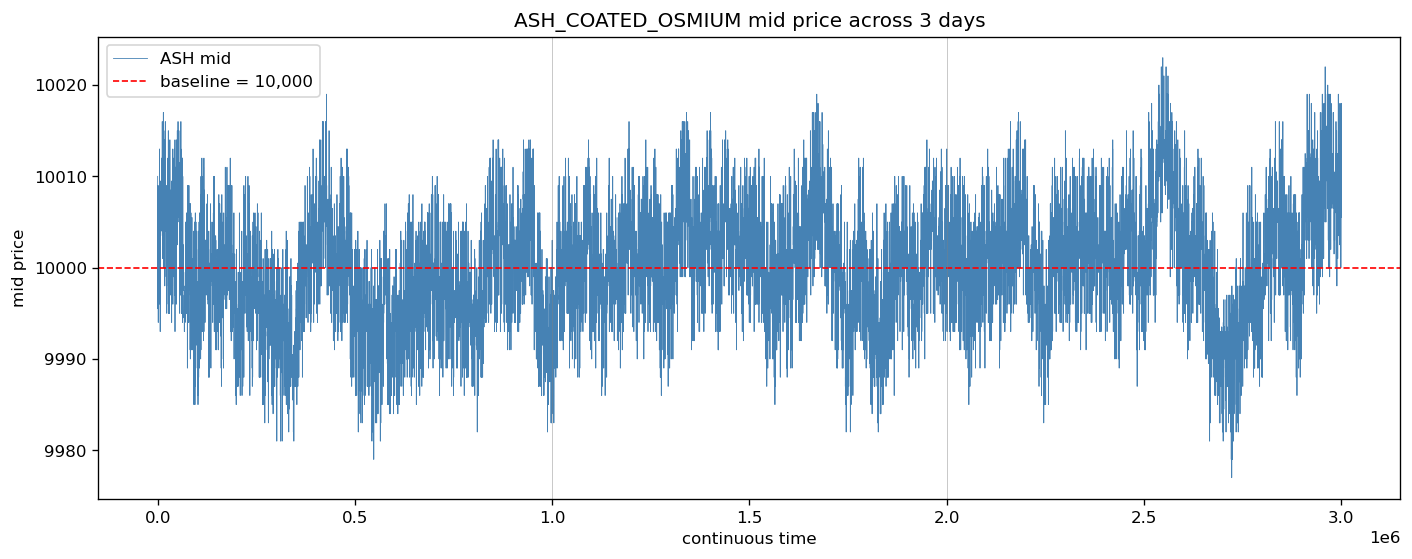

In [34]:
# 1.1 Price series with 10,000 overlay
fig, ax = plt.subplots()
ax.plot(aco["time"], aco["mid_price"], lw=0.5, color="steelblue", label="ASH mid")
ax.axhline(10_000, color="red", lw=1, ls="--", label="baseline = 10,000")
for k in range(1, len(aco["day"].unique())):
    ax.axvline(k * DAY_LEN, color="gray", lw=0.5, alpha=0.5)
ax.set_title("ASH_COATED_OSMIUM mid price across 3 days")
ax.set_xlabel("continuous time")
ax.set_ylabel("mid price")
ax.legend()
plt.show()

In [ ]:
# 1.2 Per-day and overall mean / median / std
per_day = aco.groupby("day")["mid_price"].agg(["mean", "median", "std", "min", "max", "count"])
overall = aco["mid_price"].agg(["mean", "median", "std", "min", "max", "count"]).to_frame("overall").T
print(per_day)
print()
print(overall)

             mean   median       std     min      max  count
day                                                         
-2    9998.169906   9998.0  5.219914  9979.0  10019.0   9982
-1   10000.833968  10001.0  4.450045  9982.0  10019.0   9983
 0   10001.608201  10002.0  5.683730  9977.0  10023.0   9986

                 mean   median       std     min      max    count
overall  10000.204234  10000.5  5.349695  9977.0  10023.0  29951.0


In [ ]:
# 1.3 VWAP from trades vs mid mean per day
vwap = aco_trades.groupby("day").apply(lambda d: (d["price"] * d["quantity"]).sum() / d["quantity"].sum()).rename("vwap")
mid_mean = aco.groupby("day")["mid_price"].mean().rename("mid_mean")
cmp = pd.concat([vwap, mid_mean], axis=1)
cmp["vwap - mid_mean"] = cmp["vwap"] - cmp["mid_mean"]
cmp["vwap - 10000"] = cmp["vwap"] - 10_000
print(cmp)

             vwap      mid_mean  vwap - mid_mean  vwap - 10000
day                                                           
-2    9998.262896   9998.169906         0.092990     -1.737104
-1   10000.846742  10000.833968         0.012774      0.846742
 0   10001.644578  10001.608201         0.036377      1.644578


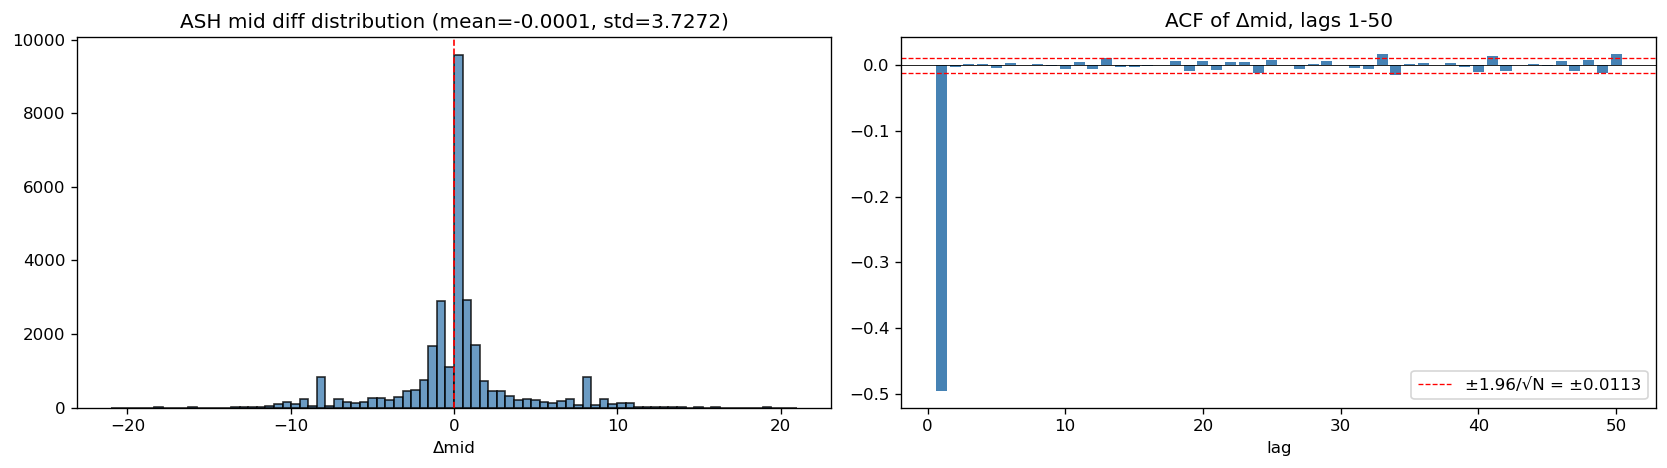

Lag-1 ACF: -0.4951  [negative ⇒ mean-reverting (likely due to bid-ask bounce), positive ⇒ momentum]


In [38]:
# 1.4 Mid-diff distribution + ACF (lags 1-50)
r = aco["ret"].dropna()
n = len(r)
ci = 1.96 / np.sqrt(n)
acf_vals = acf(r, nlags=50, fft=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(r, bins=80, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title(f"ASH mid diff distribution (mean={r.mean():+.4f}, std={r.std():.4f})")
axes[0].set_xlabel("Δmid")
axes[0].axvline(0, color="red", lw=1, ls="--")

lags = np.arange(1, 51)
axes[1].bar(lags, acf_vals[1:], color="steelblue")
axes[1].axhline(ci, color="red", lw=0.8, ls="--", label=f"±1.96/√N = ±{ci:.4f}")
axes[1].axhline(-ci, color="red", lw=0.8, ls="--")
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("ACF of Δmid, lags 1-50")
axes[1].set_xlabel("lag")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Lag-1 ACF: {acf_vals[1]:+.4f}  [negative ⇒ mean-reverting (likely due to bid-ask bounce), positive ⇒ momentum]")

In [8]:
# 1.5 ADF on (mid - 10000): is the deviation stationary?
dev = aco["mid_price"].values - 10_000
adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, _ = adfuller(dev, autolag="AIC")
print(f"ADF statistic : {adf_stat:.4f}")
print(f"p-value       : {adf_p:.3e}")
print(f"lags used     : {adf_lags}")
print(f"n obs         : {adf_nobs}")
print("critical values:")
for k, v in adf_crit.items():
    print(f"  {k}: {v:.4f}")
print("\n⇒ stationary around 10,000" if adf_p < 0.05 else "\n⇒ NOT stationary at 5% level")

ADF statistic : -5.8166
p-value       : 4.278e-07
lags used     : 28
n obs         : 29922
critical values:
  1%: -3.4306
  5%: -2.8616
  10%: -2.5668

⇒ stationary around 10,000


In [9]:
# 1.6 AR(1) half-life on (mid - 10000)
dev = aco["mid_price"].values - 10_000
y = dev[1:]
x = dev[:-1]
phi, intercept = np.polyfit(x, y, 1)
print(f"phi (AR1 coef) : {phi:+.6f}")
print(f"intercept      : {intercept:+.6f}")

if 0 < phi < 1:
    half_life = -np.log(2) / np.log(phi)
    print(f"half-life      : {half_life:.2f} ticks")
elif -1 < phi < 0:
    print("phi < 0 ⇒ over-shooting / oscillatory mean reversion (no standard half-life)")
else:
    print("phi outside (-1,1) ⇒ non-stationary; half-life undefined")

phi (AR1 coef) : +0.757256
intercept      : +0.049421
half-life      : 2.49 ticks


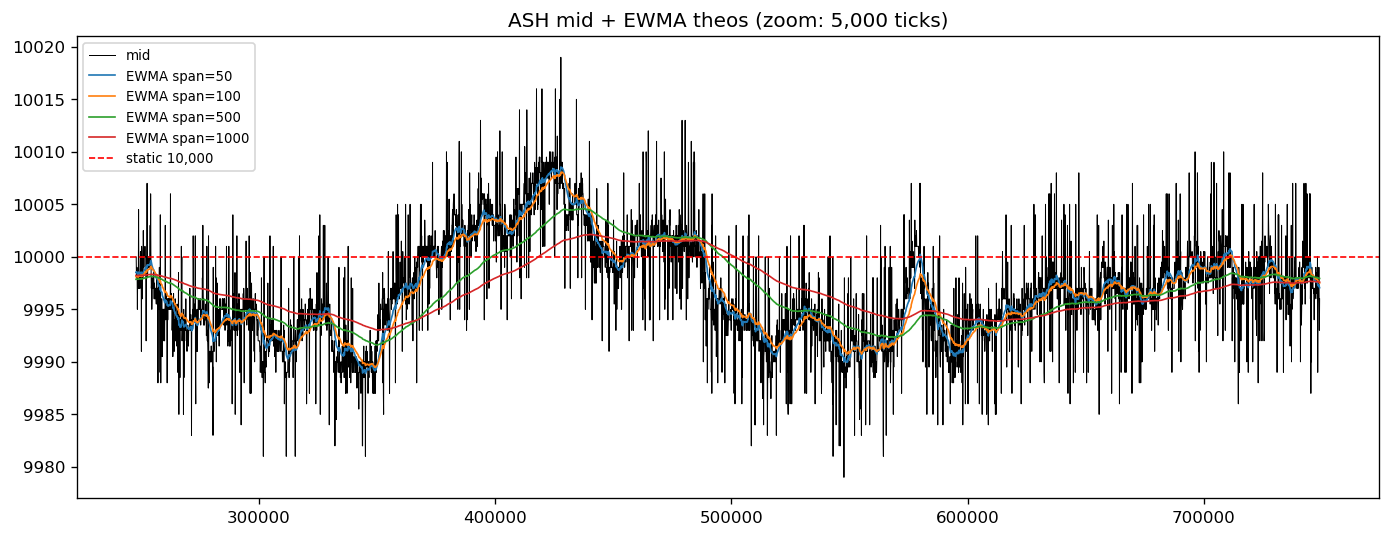

MAE of |mid_{t+H} - theo_t| (lower = better)
     static_10000  ewma_50  ewma_100  ewma_500  ewma_1000
H                                                        
1          4.1973   1.8357    2.0468    2.9240     3.3634
10         4.1983   2.0166    2.1905    2.9892     3.4040
100        4.1974   3.0472    3.1230    3.5291     3.7626


In [40]:
# 1.7 EWMA theos vs static 10,000 — visual + MAE table
spans = [50, 100, 500, 1000]
mid = aco["mid_price"]
ewmas = {s: mid.ewm(span=s, adjust=False).mean() for s in spans}

# Zoomed plot — middle 5,000 ticks
i0 = len(aco) // 2 - 2500 - 10000
i1 = i0 + 5000
fig, ax = plt.subplots()
ax.plot(aco["time"].iloc[i0:i1], mid.iloc[i0:i1], color="black", lw=0.6, label="mid")
for s in spans:
    ax.plot(aco["time"].iloc[i0:i1], ewmas[s].iloc[i0:i1], lw=1, label=f"EWMA span={s}")
ax.axhline(10_000, color="red", lw=1, ls="--", label="static 10,000")
ax.set_title("ASH mid + EWMA theos (zoom: 5,000 ticks)")
ax.legend(loc="upper left", fontsize=8)
plt.show()

# MAE: |mid_{t+H} - theo_t| at H = 1, 10, 100
horizons = [1, 10, 100]
rows = []
for H in horizons:
    future = mid.shift(-H)
    row = {"H": H, "static_10000": (future - 10_000).abs().mean()}
    for s in spans:
        row[f"ewma_{s}"] = (future - ewmas[s]).abs().mean()
    rows.append(row)
mae = pd.DataFrame(rows).set_index("H")
print("MAE of |mid_{t+H} - theo_t| (lower = better)")
print(mae.round(4))

Spread value counts:
spread
5.0       154
6.0       328
7.0       164
8.0        62
9.0       375
10.0      639
11.0      323
12.0      109
13.0      156
15.0       64
16.0    17599
17.0       34
18.0     3452
19.0     3514
20.0        4
21.0      666
22.0        1
Name: count, dtype: int64

Mean spread per day:
day
-2    16.1498
-1    16.1913
 0    16.1845
Name: spread, dtype: float64

Mean spread per intraday bucket (across all days):
intraday_bucket
0    16.1798
1    16.1712
2    16.1615
3    16.2868
4    16.1892
5    16.1545
6    16.2188
7    16.1082
8    16.1767
9    16.1065
Name: spread, dtype: float64

Mean top-of-book depth per day:
     bid_volume_1  ask_volume_1
day                            
-2          14.04         14.18
-1          14.17         14.17
 0          14.16         14.14


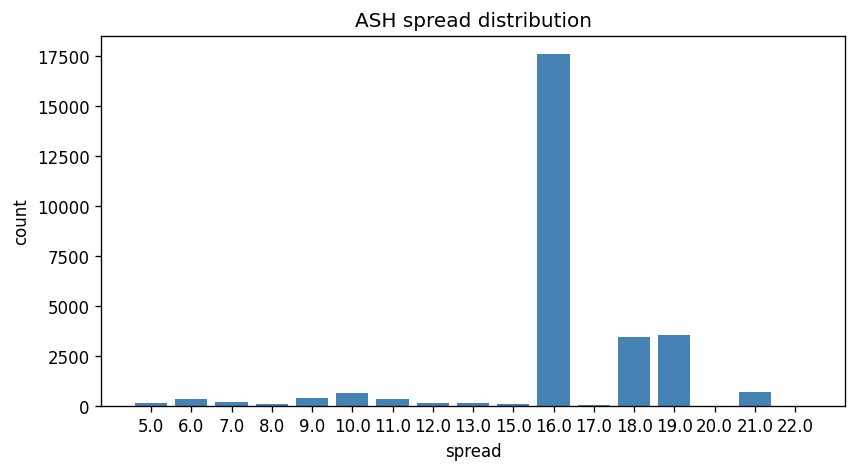

In [11]:
# 1.8 Spread distribution + book depth
spread_counts = aco["spread"].value_counts().sort_index()
print("Spread value counts:")
print(spread_counts)

print("\nMean spread per day:")
print(aco.groupby("day")["spread"].mean().round(4))

aco["intraday_bucket"] = aco["timestamp"] // 100_000  # 10 buckets per day
print("\nMean spread per intraday bucket (across all days):")
print(aco.groupby("intraday_bucket")["spread"].mean().round(4))

print("\nMean top-of-book depth per day:")
print(aco.groupby("day")[["bid_volume_1", "ask_volume_1"]].mean().round(2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(spread_counts.index.astype(str), spread_counts.values, color="steelblue")
ax.set_title("ASH spread distribution")
ax.set_xlabel("spread")
ax.set_ylabel("count")
plt.show()